## Practica Lab14: Implementación del algoritmo K-Nearest Neighbors (KNN)

## Dataset: Wine (incluido en scikit-learn)

**Carga del dataset**

from sklearn.datasets import load_wine

---

## Objetivo

Implementar el algoritmo K-Nearest Neighbors (KNN) para clasificar el cultivo de origen de distintos vinos, aplicando el flujo completo de un modelo supervisado.

Al finalizar la práctica, el estudiante será capaz de:

1. Importación de librerías
2. Carga del dataset
3. Exploración del conjunto de datos
4. Identificar variables predictoras y objetivo
5. Dividir los datos (Train/Test)
6. Escalado de variables
7. Entrenamiento del modelo KNN
8. Realizar predicciones
9. Evaluación del modelo (Accuracy)
10. Matriz de confusión
11. Classification report
12. Conclusiones

---

# Contexto del Problema

El dataset Wine contiene el resultado de un análisis químico de vinos cultivados en la misma región de Italia, pero provenientes de **tres cultivos distintos**.

Cada registro describe un vino mediante 13 mediciones químicas (alcohol, magnesio, flavonoides, etc.). El objetivo será construir un modelo capaz de predecir a cuál de los tres cultivos pertenece un vino a partir de esas mediciones:

- class_0
- class_1
- class_2

*Nota: el enunciado menciona "especies de flores", pero ese es el problema del Lab13 (Iris). El dataset Wine no clasifica flores sino el cultivo de origen del vino; el flujo del algoritmo es el mismo.*

---

# Entregables

El repositorio deberá contener:

```text
Notebooks/
└── Lab14.ipynb
```

---

In [1]:
#Importamos librerias
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
accuracy_score,
confusion_matrix,
classification_report,
ConfusionMatrixDisplay
)
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Cargamos el dataset Wine
from sklearn.datasets import load_wine
wine = load_wine(as_frame = True)

In [3]:
print (wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [4]:
dfWine = wine.frame
dfWine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Exploracion del conjunto de datos

In [5]:
dfWine.shape

(178, 14)

In [6]:
dfWine.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')

In [7]:
dfWine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [8]:
dfWine.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [9]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [10]:
#Verificamos valores nulos
dfWine.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [11]:
### Renombrar la columna "target"

dfWine.rename(columns = {"target" : "cultivo"}, inplace = True)

In [12]:
dfWine["cultivo"] = dfWine["cultivo"].map({
    0: "class_0",
    1: "class_1",
    2: "class_2"
})

In [13]:
dfWine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivo
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [14]:
dfWine.tail()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivo
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.7,0.64,1.74,740.0,class_2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.3,0.70,1.56,750.0,class_2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.2,0.59,1.56,835.0,class_2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.3,0.60,1.62,840.0,class_2
177,14.13,4.10,2.74,24.5,96.0,2.05,0.76,0.56,1.35,9.2,0.61,1.60,560.0,class_2


In [15]:
#Distribucion de la variable objetivo
dfWine["cultivo"].value_counts()

cultivo
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

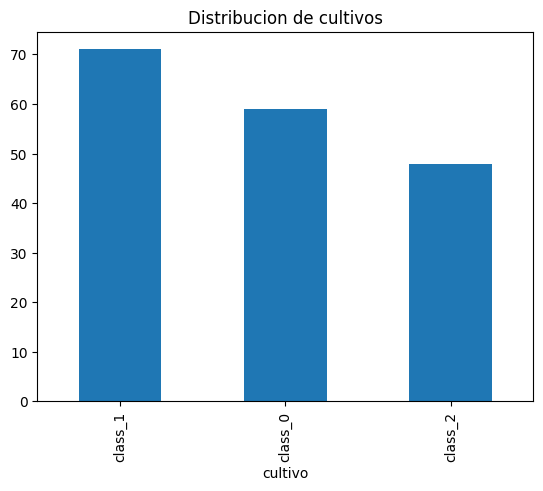

In [16]:
#Graficamos la distribucion
dfWine["cultivo"].value_counts().plot(
    kind = "bar"
)
plt.title("Distribucion de cultivos")
plt.show()

## Identificar variables predictoras y variables objetivos

In [17]:
#Variable predictora
X = dfWine.drop(columns = ["cultivo"])

In [18]:
print("Variables predictoras")
print(X.columns)

Variables predictoras
Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')


In [19]:
#Varible objetivo
y = dfWine["cultivo"]

In [20]:
print("Variable objetivo")
print(y.name)

Variable objetivo
cultivo


## Dividir los datos

80% para entrenamiento

20% para prueba

Usamos `stratify=y` para que las tres clases mantengan su proporcion en ambos conjuntos.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.20, random_state= 42, stratify=y
)

In [22]:
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (142, 13)
X_test (36, 13)
y_train (142,)
y_test (36,)


## Escalado de variables

KNN clasifica midiendo distancias entre registros, por lo que la escala de cada variable afecta directamente el resultado.

En este dataset las escalas son muy distintas: `proline` llega a valores de ~1680 mientras que `hue` se mueve alrededor de 1. Sin escalar, `proline` dominaria el calculo de la distancia y las demas variables casi no aportarian.

In [23]:
scaler = StandardScaler()

In [24]:
# Escalamos las variables
X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.transform(X_test)

In [25]:
print("Sin escalar")
print(X_train.head())

print("Escalado")
print(X_train_escalado[:5])

Sin escalar
     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
36     13.28        1.64  2.84               15.5      110.0           2.60   
30     13.73        1.50  2.70               22.5      101.0           3.00   
26     13.39        1.77  2.62               16.1       93.0           2.85   
12     13.75        1.73  2.41               16.0       89.0           2.60   
148    13.32        3.24  2.38               21.5       92.0           1.93   

     flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
36         2.68                  0.34             1.36             4.60  1.09   
30         3.25                  0.29             2.38             5.70  1.19   
26         2.94                  0.34             1.45             4.80  0.92   
12         2.76                  0.29             1.81             5.60  1.15   
148        0.76                  0.45             1.25             8.42  0.55   

     od280/od315_of_dilute

## Entrenamiento del modelo KNN
En esta prueba utilizaremos k = 5

In [26]:
modelo = KNeighborsClassifier(n_neighbors= 5)

In [27]:
modelo.fit(
    X_train_escalado, y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['class_0','class_1','class_2']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## Realizamos predicciones con las variables de Prueba

In [28]:
prediccion = modelo.predict(X_test_escalado)

In [29]:
print (prediccion[:10])

['class_0' 'class_2' 'class_0' 'class_1' 'class_1' 'class_0' 'class_0'
 'class_1' 'class_1' 'class_2']


In [30]:
#Comparación entre valores reales y valores predecibles
comparacion = pd.DataFrame({
    "cultivo real": y_test.values,
    "cultivo predicho": prediccion
})

In [31]:
comparacion.head(10)

,cultivo real,cultivo predicho
0,class_0,class_0
1,class_2,class_2
2,class_0,class_0
3,class_1,class_1
4,class_1,class_1
5,class_0,class_0
6,class_0,class_0
7,class_1,class_1
8,class_1,class_1
9,class_2,class_2


## Evaluación del modelo

In [32]:
accuracy = accuracy_score(y_test, prediccion)
print(f"accuracy/exactitud: {accuracy: .4f}")

accuracy/exactitud:  0.9722


In [33]:
## Matriz de confusion
cm = confusion_matrix(y_test, prediccion)

In [34]:
cm_df = pd.DataFrame(
    cm,
    index= modelo.classes_,
    columns= modelo.classes_
)
cm_df

,class_0,class_1,class_2
class_0,12,0,0
class_1,0,13,1
class_2,0,0,10


## Clasificacion report
Proporciona métricas que permitan evaluar el desempeño de cada clase: precission, recall, f1-score, support

In [35]:
print(classification_report(y_test, prediccion))

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      0.93      0.96        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



## Comparación del valor de k

Probamos distintos valores de k para verificar que k=5 es una eleccion adecuada y no un resultado de suerte.

In [36]:
#Probamos varios valores de k
resultados_k = []

for k in range(1, 16):
    modelo_k = KNeighborsClassifier(n_neighbors= k)
    modelo_k.fit(X_train_escalado, y_train)
    pred_k = modelo_k.predict(X_test_escalado)
    resultados_k.append({
        "k": k,
        "Accuracy": accuracy_score(y_test, pred_k)
    })

dfResultadosK = pd.DataFrame(resultados_k)
dfResultadosK

,k,Accuracy
0,1,0.972222
1,2,0.944444
2,3,0.972222
3,4,0.944444
4,5,0.972222
5,6,0.972222
6,7,1.000000
7,8,1.000000
8,9,1.000000
9,10,1.000000


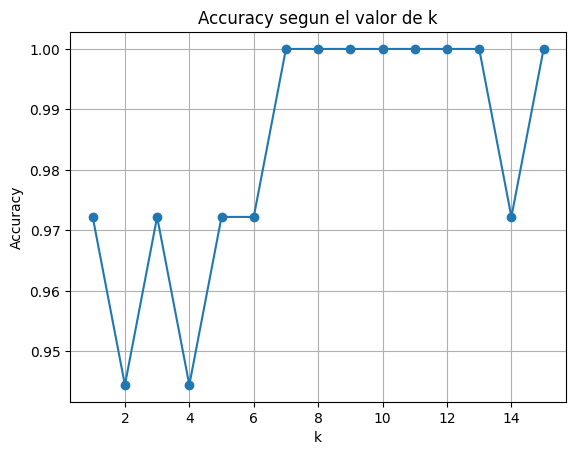

In [37]:
#Graficamos el accuracy por cada valor de k
plt.plot(
    dfResultadosK["k"],
    dfResultadosK["Accuracy"],
    marker = "o"
)
plt.title("Accuracy segun el valor de k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

## Conclusiones

**Resultado obtenido:** el modelo KNN con k=5 alcanzo un **accuracy de 0.9722** sobre el conjunto de prueba, es decir, clasifico correctamente 35 de los 36 vinos. Segun la tabla de interpretacion usada en el Lab12 (>90% = "Excelente"), es un resultado muy alto.

**¿Donde fallo el modelo?** La matriz de confusion muestra un unico error: un vino de `class_1` fue clasificado como `class_2`. Las clases `class_0` y `class_2` se predijeron sin ningun error. Esto se refleja en el classification report: `class_1` tiene recall de 0.93 (perdio 1 de sus 14 vinos) y `class_2` tiene precision de 0.91 (recibio ese vino ajeno). `class_0` obtuvo 1.00 en las tres metricas, lo que sugiere que es el cultivo mas facilmente separable de los tres.

**Decisiones tomadas durante la limpieza y preparacion:**

- **No hubo valores nulos que tratar.** `isnull().sum()` devolvio 0 en las 14 columnas, por lo que no fue necesaria ninguna imputacion, a diferencia del Lab12 (Adult Income) donde `workclass` y `occupation` sí requirieron imputar con la moda.
- **No fue necesario One-Hot Encoding.** Las 13 variables predictoras son todas numericas (mediciones quimicas), asi que no hubo texto que codificar. La unica variable categorica es la objetivo (`cultivo`), y esa no se codifica.
- **Se renombro `target` a `cultivo`** y se mapearon los valores 0, 1 y 2 a `class_0`, `class_1` y `class_2` para que las salidas del modelo sean legibles en lugar de numeros sin significado.
- **Se uso `stratify=y` en el split.** Las clases estan desbalanceadas (71 / 59 / 48 registros), y con solo 36 vinos en prueba, un split sin estratificar podria dejar alguna clase con muy pocos representantes y distorsionar la evaluacion.

**El escalado fue la decision mas importante.** KNN clasifica midiendo distancias entre registros, por lo que una variable con valores grandes domina el calculo. En este dataset `proline` llega a ~1680 mientras que `hue` se mueve alrededor de 1: sin escalar, la distancia entre dos vinos seria practicamente la diferencia de `proline` y las otras 12 mediciones casi no aportarian. Aplicar `StandardScaler` (ajustado solo con `X_train` y despues aplicado a `X_test`) deja todas las variables en la misma escala y es lo que permite que el modelo aproveche las 13 mediciones.

**¿Fue k=5 una buena eleccion?** Al probar k de 1 a 15 se observo que k=5 da 0.9722, pero los valores de **k entre 7 y 13 alcanzan accuracy de 1.0000**. Tambien se ve que los valores pares (k=2 y k=4) bajan a 0.9444, lo que tiene sentido porque con 3 clases un k par favorece mas los empates entre vecinos. En principio convendria usar k=7.

**Limitaciones — por que no hay que celebrar el 100%:**

- El conjunto de prueba es muy pequeño (36 registros). **Un solo vino mal clasificado mueve el accuracy 2.8 puntos**, asi que la diferencia entre k=5 (0.9722) y k=7 (1.0000) es literalmente un caso. No es evidencia suficiente para afirmar que k=7 es mejor.
- Ese 1.0000 se esta midiendo sobre el mismo conjunto de prueba que se uso para elegir k, lo que sesga el resultado a favor. Elegir el k que maximiza el accuracy de prueba es, en la practica, ajustar el modelo a los datos de prueba.
- Lo correcto seria elegir k con **validacion cruzada sobre el conjunto de entrenamiento** (`cross_val_score`) y reservar el conjunto de prueba para una unica evaluacion final.
- El dataset es pequeño (178 registros) y proviene de una sola region de Italia, por lo que el modelo no necesariamente generalizaria a vinos de otros origenes.